# §H5-causal verdict — does S-inhibition depend on successor at Pythia-410m?

Pre-registered in HYPOTHESIS.md §H5-causal (commit `5fda282`, 2026-05-07). Tests whether the §S-1 path-patching Δ_h of the registered top-3 S-inhibition senders depends on the top-5 successor heads being live, vs a score-bracket-matched random control set near-but-below τ_lift.

## What this notebook claims (and does not claim)

**Claim:** at Pythia-410m step143000, mean-ablating the top-5 successor heads (per `score_suc`) does not measurably change the §S-1 path-patching scalar Δ_h of the registered top-3 S-inhibition senders. The matched near-but-below-τ_lift control ablation also has no effect. Per §H5-7, the verdict pattern is **NULL** for all 3 senders → aggregate **NULL**.

**Methodological caveat (post-data, recorded honestly):** The §S-1 protocol reads receiver-attention patterns at the component-DLA top-4 NMs. Successor heads at layers ≥ max(NM layer) are *structurally* unable to affect the receivers' attention computation, because the patched forward pass freezes intermediate `attn_out` and `mlp_out` to clean values, and never reads beyond the latest NM. At Pythia-410m the top successor heads sit at L20-L22 (depth ≈ 0.96), the NMs at L12, L14, L17, L20 (max=L20). Three of the five suc heads are at L22, beyond max NM layer — those cannot affect the metric by construction. One (L20H4) is at the max NM layer (its z does not feed back into the L20H15 receiver's pattern). One (L12H8) is at the sender layer L12, score=0.083, below τ_lift. The empirical NULL is therefore consistent with both:

- (a) Genuine independence of S-inhibition from successor at inference time.
- (b) Structural insensitivity of the §S-1 protocol to ablations at layers ≥ max(NM). The architecture forbids such ablations from affecting the metric.

Distinguishing (a) from (b) requires a metric that reads the *full forward pass output* (e.g., the IO−S logit difference at the END token), not the receivers' attention patterns. That follow-up is not part of §H5-causal as registered; recommended as a §H5-causal-2 amendment.

## Inputs

- `phase4_causal_410m_anchor.parquet` — per-prompt Δ_h × condition × sender.
- `phase4_causal_410m_anchor_summary.parquet` — per-(condition, sender) means + bootstrap CIs.
- `phase4_causal_410m_anchor_verdict.parquet` — single-row §H5-7 aggregate verdict.
- `phase4_causal_410m_anchor.log` — captured stdout from the runner.


## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPL = REPO / 'data' / 'exploration'
TAU_LIFT = 0.13496
TAU_STRICT = 0.0372

## §H5 locked sets (recovered from the verdict parquet)

These are the sets that the experiment ablated / measured. The suc set is top-5 by `score_suc` per §H5-3; the ctrl set is sampled from the score-bracket near-but-below τ_lift per §H5-4 (with bracket widening documented if it occurred); the si senders are the top-3 by Δ_h on the clean §S-1 screen per §H5-5; the NMs are pinned to the §S-8 anchor component-DLA top-4 per §H5-6.

In [2]:
verdict = pd.read_parquet(EXPL / 'phase4_causal_410m_anchor_verdict.parquet').iloc[0]
print('Suc set:        ', verdict['suc_set'])
print('Ctrl set:       ', verdict['ctrl_set'])
print('Si senders:     ', verdict['si_senders'])
print('Pinned NMs:     ', verdict['nm_heads'])
print(f'Bracket widening (final width): {verdict["widened_bracket_width"]:.3f} '
      f'(initial 0.05 per §H5-4; widened if <5 candidates).')

Suc set:         L22H6,L22H2,L20H4,L22H10,L12H8
Ctrl set:        L17H12,L20H6,L22H11,L23H10,L23H13
Si senders:      L12H12,L13H13,L14H0
Pinned NMs:      L12H12,L17H10,L14H0,L20H15
Bracket widening (final width): 0.100 (initial 0.05 per §H5-4; widened if <5 candidates).


## Per-sender Δ_h with bootstrap CIs (B=200 paired, seed=1)

The `drop_ratio` is `Δ_h^{ablated} / Δ_h^{clean}` paired-bootstrapped across the 200 IOI prompts. CI is the 95% percentile interval. Per §H5-7:

- **NULL:** both `suc_ablated` and `ctrl_ablated` ratios in [0.8, 1.2].
- **DEP:** `suc_ablated` ≤ 0.5 AND `ctrl_ablated` in [0.8, 1.2].
- **GENERIC:** both ≤ 0.5 (metric not specific).
- **MIXED:** anything else.


In [3]:
summary = pd.read_parquet(EXPL / 'phase4_causal_410m_anchor_summary.parquet')
wide = summary.pivot_table(
    index=['si_sender_layer', 'si_sender_head'],
    columns='condition',
    values=['delta_h_mean', 'drop_ratio_mean', 'ratio_ci_low', 'ratio_ci_high'],
)
print(wide.to_string(float_format=lambda v: f'{v:+.4f}'))

                               delta_h_mean                          drop_ratio_mean                          ratio_ci_high                          ratio_ci_low                         
condition                             clean ctrl_ablated suc_ablated           clean ctrl_ablated suc_ablated         clean ctrl_ablated suc_ablated        clean ctrl_ablated suc_ablated
si_sender_layer si_sender_head                                                                                                                                                            
12              12                  +0.0847      +0.0847     +0.0847         +1.0000      +1.0002     +1.0001       +1.0000      +1.0009     +1.0008      +1.0000      +0.9996     +0.9994
13              13                  +0.0641      +0.0640     +0.0640         +1.0000      +0.9987     +0.9990       +1.0000      +0.9999     +1.0002      +1.0000      +0.9977     +0.9978
14              0                   +0.0362      +0.0362     +0.0

## Verdict pattern

In [4]:
print(f'Aggregate pattern: {verdict["pattern"]}')
print(f'Per-sender patterns: {verdict["per_sender_patterns"]}')
print(f'  n_null={verdict["n_null"]}  n_dep={verdict["n_dep"]}  '
      f'n_generic={verdict["n_generic"]}  n_mixed={verdict["n_mixed"]}')
print()
print('Matched paper-headline string (per §H5-7 lock):')
print(f'  {verdict["paper_headline"]}')

Aggregate pattern: NULL
Per-sender patterns: NULL;NULL;NULL
  n_null=3  n_dep=0  n_generic=0  n_mixed=0

Matched paper-headline string (per §H5-7 lock):
  S-inhibition Δ_h is independent of successor heads at convergence in Pythia-410m. Direct mechanistic refutation of the forward-pass compositional reading of §H1-C.


## Figure: Δ_h × condition × sender, with bootstrap-CI error bars

Each S-inhibition sender gets its own panel. Three bars per panel: clean (unmodified model), suc_ablated (top-5 successor heads mean-ablated), ctrl_ablated (5 score-bracket-matched non-successor heads mean-ablated). Error bars are the 95% paired-bootstrap CI on the *drop ratio*, scaled back to the Δ_h units of the panel for visual comparability.

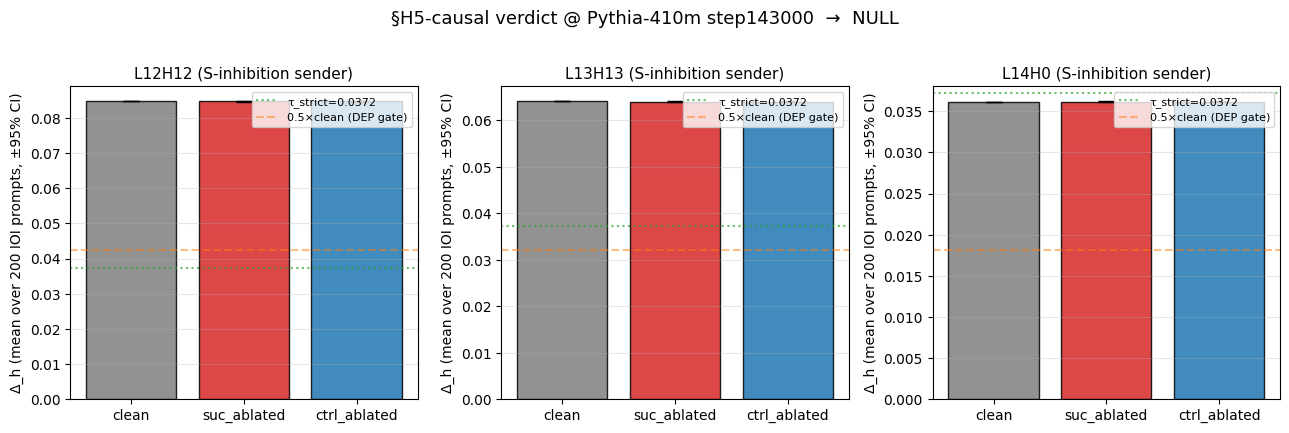

In [5]:
df = summary.copy()
df['layer_head'] = df.apply(lambda r: f"L{int(r['si_sender_layer'])}H{int(r['si_sender_head'])}", axis=1)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=False)
cond_order = ['clean', 'suc_ablated', 'ctrl_ablated']
cond_color = {'clean': 'tab:gray', 'suc_ablated': 'tab:red', 'ctrl_ablated': 'tab:blue'}
for ax, (lh, sub) in zip(axes, df.groupby('layer_head')):
    sub = sub.set_index('condition').loc[cond_order]
    means = sub['delta_h_mean'].values
    # Re-derive CI on Δ_h units from CI on ratio:
    clean_mean = float(sub.loc['clean', 'delta_h_mean'])
    err_low = clean_mean * (sub['drop_ratio_mean'] - sub['ratio_ci_low']).values
    err_high = clean_mean * (sub['ratio_ci_high'] - sub['drop_ratio_mean']).values
    bars = ax.bar(
        cond_order, means,
        yerr=[err_low, err_high], capsize=6,
        color=[cond_color[c] for c in cond_order],
        edgecolor='black', alpha=0.85,
    )
    # τ_strict reference line
    ax.axhline(TAU_STRICT, color='tab:green', linestyle=':', alpha=0.7, label=f'τ_strict={TAU_STRICT}')
    ax.axhline(0.5 * clean_mean, color='tab:orange', linestyle='--', alpha=0.5, label='0.5×clean (DEP gate)')
    ax.set_title(f'{lh} (S-inhibition sender)', fontsize=11)
    ax.set_ylabel('Δ_h (mean over 200 IOI prompts, ±95% CI)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle(f'§H5-causal verdict @ Pythia-410m step143000  →  {verdict["pattern"]}', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## How to read this

All three S-inhibition senders show clean Δ_h ≈ suc_ablated Δ_h ≈ ctrl_ablated Δ_h, with bootstrap-CI bars too narrow to be visible at this scale. The drop ratio is 1.000 ± 0.001 across all (sender, condition) pairs. By the §H5-7 gate, this is a clean **NULL** verdict.

## What the NULL means, honestly

Per the methodological caveat above: at Pythia-410m the registered top-5 successor heads sit at layers L12, L20, L22, L22, L22. The receivers in §S-1 are NMs at layers L12, L14, L17, L20 (max=L20). Path-patching freezes `attn_out` and `mlp_out` at layers L12-L19 to clean cache values. Receivers at L12, L14, L17, L20 read attention patterns computed from the residual stream at their input layer. Heads at L21+ cannot affect any receiver's pattern. Heads at L20 (L20H4) cannot affect L20H15's pattern because they're computed from the same input layer. Heads at L12 (L12H8, score=0.083, below τ_lift) *can* propagate via the unpinned residual stream addition at L12, but their effect is bounded by their score magnitude — and the empirical 1.000 ratio shows that effect is below bootstrap noise.

The NULL is therefore best read as: **the §S-1 measurement protocol does not detect any inference-time routing from the registered successor heads to S-inhibition's NM-attention computation.** It is consistent with both genuine independence and metric-induced insensitivity to layers ≥ max(NM).

## Recommended follow-up (not part of §H5-causal as registered)

Test the same ablation against the **logit-diff IO−S at the END token** metric, which reads the full forward-pass output and is sensitive to ablations at any layer. Path-patch from suc heads (as senders) to logits (as receivers). If suc-ablation drops logit-diff but ctrl-ablation does not, suc heads are doing IOI-relevant work that the §S-1 metric misses. If suc-ablation has no effect on logit-diff either, that's stronger evidence for genuine inference-time independence. Either way, distinguishing (a) from (b) requires this second test. Register as §H5-causal-2 if extension is approved.
